# LLM Translation Benchmark: EN → ID
**Dataset:** OPUS ELRC_2922 — English ↔ Indonesian parallel corpus  
**Models compared:** Claude (Anthropic) · GPT-4o (OpenAI) · Grok (xAI) · DeepSeek  
**Metrics:** Translation quality (BLEU / chrF), latency, token usage, and total cost

---
***Models Comparison Table:***
| Provider | Model | Input ($/1M) | Output ($/1M) | Context Window | Status |
|---|---|---|---|---|---|
| Anthropic | Claude Fable 5 | $10.00 | $50.00 | 1M | ✅ Newest flagship |
| Anthropic | Claude Mythos 5 | $10.00 | $50.00 | 1M | ✅ Project Glasswing only |
| Anthropic | Claude Opus 4.8 | $5.00 | $25.00 | 1M | ✅ Current |
| Anthropic | Claude Opus 4.7 | $5.00 | $25.00 | 1M | ✅ Current |
| Anthropic | Claude Opus 4.6 | $5.00 | $25.00 | 1M | ✅ Current |
| Anthropic | Claude Sonnet 4.6 | $3.00 | $15.00 | 1M | ✅ Recommended production |
| Anthropic | Claude Haiku 4.5 | $1.00 | $5.00 | 200K | ✅ Budget / high-volume |
| Anthropic | Claude Haiku 3.5 | $0.80 | $4.00 | 200K | ⚠️ Legacy |
| Anthropic | Claude Haiku 3 | $0.25 | $1.25 | 200K | ⚠️ Legacy |
| Anthropic | Claude Opus 4.1 | $15.00 | $75.00 | 200K | ⚠️ Legacy |
| OpenAI | GPT-5.5 Pro | $30.00 | $180.00 | 1M+ | ✅ Highest-stakes reasoning |
| OpenAI | GPT-5.5 | $5.00 | $30.00 | 1M+ | ✅ Current flagship |
| OpenAI | GPT-5.4 | $2.50 | $15.00 | 1M | ✅ Recommended production |
| OpenAI | GPT-5.4 Mini | $0.75 | $4.50 | 1M | ✅ Budget general use |
| OpenAI | GPT-5.4 Nano | $0.20 | $1.25 | 1M | ✅ Ultra-budget |
| OpenAI | o3-pro | $20.00 | $80.00 | 200K | ✅ Max reasoning |
| OpenAI | o3 | $2.00 | $8.00 | 200K | ✅ Reasoning |
| OpenAI | o4-mini | $1.10 | $4.40 | 200K | ✅ Affordable reasoning |
| OpenAI | GPT-4.1 | $2.00 | $8.00 | 1M | ✅ Long-context budget |
| OpenAI | GPT-4.1 Mini | $0.40 | $1.60 | 1M | ✅ Long-context budget |
| OpenAI | GPT-4.1 Nano | $0.10 | $0.40 | 1M | ✅ Cheapest in lineup |
| OpenAI | GPT-4o | $2.50 | $10.00 | 128K | ⚠️ Legacy multimodal |
| OpenAI | GPT-4o Mini | $0.15 | $0.60 | 128K | ⚠️ Legacy budget |
| xAI | Grok 4.20 | $2.00 | $6.00 | 2M | ✅ Current (multi-agent capable) |
| xAI | Grok 4.3 | $1.25 | $2.50 | 1M | ✅ Current flagship |
| xAI | Grok Build 0.1 | $1.00 | $2.00 | 256K | ✅ Agentic coding |
| xAI | Grok 4.1 Fast | $0.20 | $0.50 | 2M | ✅ Budget / high-volume |
| xAI | Grok 4 | $3.00 | $15.00 | 256K | ⚠️ Legacy |
| xAI | Grok 3 | $2.00 | $10.00 | 131K | ⚠️ Legacy |
| xAI | Grok 3 Mini | $0.30 | $0.50 | 131K | ⚠️ Legacy |
| DeepSeek | DeepSeek V4 Pro | $1.74 | $3.48 | 1M | ✅ Flagship reasoning |
| DeepSeek | DeepSeek V4 Flash | $0.14 | $0.28 | 1M | ✅ Cost-effective flagship |
| DeepSeek | deepseek-chat *(alias)* | $0.14 | $0.28 | 1M | ⚠️ → V4 Flash (deprecated Jul 24, 2026) |
| DeepSeek | deepseek-reasoner *(alias)* | $0.14 | $0.28 | 1M | ⚠️ → V4 Flash thinking (deprecated Jul 24, 2026) |


---

#### Summary — Cheapest & Most Expensive Per Provider

| Provider | Cheapest Input | Cheapest Output | Most Expensive Input | Most Expensive Output |
|---|---|---|---|---|
| **Anthropic** | $0.25 (Haiku 3) | $1.25 (Haiku 3) | $15.00 (Opus 4.1) | $75.00 (Opus 4.1) |
| **OpenAI** | $0.10 (GPT-4.1 Nano) | $0.40 (GPT-4.1 Nano) | $30.00 (GPT-5.5 Pro) | $180.00 (GPT-5.5 Pro) |
| **xAI** | $0.20 (Grok 4.1 Fast) | $0.50 (Grok 3 Mini / 4.1 Fast) | $3.00 (Grok 4) | $15.00 (Grok 4) |
| **DeepSeek** | $0.14 (V4 Flash) | $0.28 (V4 Flash) | $1.74 (V4 Pro) | $3.48 (V4 Pro) |

---

*Prices are subject to change. Always verify against official provider documentation before committing to production budgets.*
- Anthropic: https://platform.claude.com/docs/en/about-claude/pricing  
- OpenAI: https://developers.openai.com/api/docs/pricing  
- xAI: https://docs.x.ai/docs/models  
- DeepSeek: https://api-docs.deepseek.com/quick_start/pricing


## 1. Install dependencies

In [1]:
%pip install -q anthropic openai requests sacrebleu pandas matplotlib seaborn tqdm python-dotenv

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## 2. Configuration — API keys & model names
Set your keys in a `.env` file or directly below.

In [2]:
import os
from dotenv import load_dotenv


# Load API keys from API_KEY.txt if it exists
if os.path.exists("API_KEY.txt"):
    with open("API_KEY.txt", "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip()

load_dotenv()

# ── API Keys ──────────────────────────────────────────────────────────────────
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")
OPENAI_API_KEY    = os.getenv("OPENAI_API_KEY",    "")
XAI_API_KEY       = os.getenv("XAI_API_KEY",       "")
DEEPSEEK_API_KEY  = os.getenv("DEEPSEEK_API_KEY",  "")

# ── Model identifiers ─────────────────────────────────────────────────────────
MODELS = {
    "claude":   "claude-sonnet-4-6",
    "openai":   "gpt-4o",
    "xai":      "grok-3",
    "deepseek": "deepseek-chat",
}

# ── Pricing (USD per 1 M tokens) — update as needed ──────────────────────────
# Format: {model_key: (input_price_per_1M, output_price_per_1M)}
PRICING = {
    "claude":   (3.00,  15.00),   # claude-sonnet-4-6
    "openai":   (2.50,  10.00),   # gpt-4o
    "xai":      (2.00,  10.00),   # grok-3 (verify on x.ai)
    "deepseek": (0.14,   0.28),   # deepseek-chat V3
}

# ── Benchmark settings ────────────────────────────────────────────────────────
N_SAMPLES       = 100   # number of sentence pairs to evaluate
REQUEST_TIMEOUT = 60   # seconds per request

print("Configuration loaded.")

Configuration loaded.


## 3. Load the OPUS ELRC_2922 EN–ID sample dataset

In [3]:
import pandas as pd

# ── Load parallel corpus from local TSV ──────────────────────────────────────
TSV_PATH = "../../data/ELRC2922-v1-en2id.tsv"

df_dataset = pd.read_csv(
    TSV_PATH,
    sep="	",
    header=None,
    names=["source_en", "reference_id"],
)

# Strip leading/trailing whitespace from both columns
df_dataset["source_en"]   = df_dataset["source_en"].str.strip()
df_dataset["reference_id"] = df_dataset["reference_id"].str.strip()
print(f"Loaded raw {len(df_dataset)} sentence pairs from {TSV_PATH}")

# Limit to N_SAMPLES
df_dataset = df_dataset.head(N_SAMPLES)

print(f"Loaded {len(df_dataset)} sentence pairs from {TSV_PATH}")
df_dataset.head(30)

Loaded raw 100 sentence pairs from ../../data/ELRC2922-v1-en2id.tsv
Loaded 100 sentence pairs from ../../data/ELRC2922-v1-en2id.tsv


,source_en,reference_id
0,While there is tentative data that it is safe ...,Meskipun secara umum aman dan dengan data hewa...
1,"Rhabdomyolysis occurs in about 26,000 people a...",Rabdomiolisis dialami oleh sekitar 26.000 oran...
2,""" The primary health care approach has since t...",""" Semenjak itu , pendekatan yang menekankan pe..."
3,Prior to the establishment of a quarantine fac...,Salah satu kamp karantina pertama terletak di ...
4,"As before , the viruses adhere to the cell thr...","Seperti sebelumnya , virus akan berikatan mela..."
5,"Macrophages , epithelioid cells , T lymphocyte...","Sel-sel seperti Makrofag , limfosit T , limfos..."
6,"For example , lymphocyte T-cell immunomodulato...",Contohnya Lymphocyte T-Cell Immune Modulator m...
7,The hospital was suspected as the source of th...,Rumah sakit itu dicurigai sebagai sumber wabah...
8,"On 20 February , three more cases were confirm...",Tiga kasus lagi dikonfirmasi pada hari yang sa...
9,Lombardy governor Attilio Fontana announced th...,Gubernur Lombardy Attilio Fontana mengumumkan ...


## 4. API client helpers

Each helper calls the provider and returns:  
`{translation, latency_s, input_tokens, output_tokens, cost_usd}`

In [6]:
import time
import anthropic
import openai

SYSTEM_PROMPT = (
    "You are a professional translator. "
    "Translate the following English text to Indonesian. "
    "Output ONLY the translation, no explanations."
)


def _cost(model_key, in_tok, out_tok):
    ip, op = PRICING[model_key]
    return (in_tok * ip + out_tok * op) / 1_000_000


# ── Claude (Anthropic) ────────────────────────────────────────────────────────
def translate_claude(text):
# Load API keys from API_KEY.txt if it exists
    # if os.path.exists("API_KEY.txt"):
    #     with open("API_KEY.txt", "r") as f:
    #         for line in f:
    #             line = line.strip()
    #             if line and not line.startswith("#") and "=" in line:
    #                 key, val = line.split("=", 1)
    #                 os.environ[key.strip()] = val.strip()

    if not ANTHROPIC_API_KEY:
        raise ValueError("ANTHROPIC_API_KEY belum terbaca dari .env") # Loaded from .env

    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    t0 = time.perf_counter()
    msg = client.messages.create(
        model=MODELS["claude"], max_tokens=512,
        system=SYSTEM_PROMPT,
        messages=[{"role": "user", "content": text}],
    )
    lat = time.perf_counter() - t0
    return {
        #"translation":   msg.content[0].text.strip(),
        "translation":   msg.content[0].text.strip() if msg.content else "",
        "latency_s":     lat,
        "input_tokens":  msg.usage.input_tokens,
        "output_tokens": msg.usage.output_tokens,
        "cost_usd":      _cost("claude", msg.usage.input_tokens, msg.usage.output_tokens),
    }


# ── OpenAI (GPT-4o) ───────────────────────────────────────────────────────────
def translate_openai(text):
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=MODELS["openai"], max_tokens=512,
        messages=[{"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user",   "content": text}],
    )
    lat = time.perf_counter() - t0
    return {
        "translation":   resp.choices[0].message.content.strip(),
        "latency_s":     lat,
        "input_tokens":  resp.usage.prompt_tokens,
        "output_tokens": resp.usage.completion_tokens,
        "cost_usd":      _cost("openai", resp.usage.prompt_tokens, resp.usage.completion_tokens),
    }


# ── xAI / Grok (OpenAI-compatible) ────────────────────────────────────────────
def translate_xai(text):
    client = openai.OpenAI(api_key=XAI_API_KEY, base_url="https://api.x.ai/v1")
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=MODELS["xai"], max_tokens=512,
        messages=[{"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user",   "content": text}],
    )
    lat = time.perf_counter() - t0
    return {
        "translation":   resp.choices[0].message.content.strip(),
        "latency_s":     lat,
        "input_tokens":  resp.usage.prompt_tokens,
        "output_tokens": resp.usage.completion_tokens,
        "cost_usd":      _cost("xai", resp.usage.prompt_tokens, resp.usage.completion_tokens),
    }


# ── DeepSeek (OpenAI-compatible) ──────────────────────────────────────────────
def translate_deepseek(text):
    client = openai.OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com/v1")
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=MODELS["deepseek"], max_tokens=512,
        messages=[{"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user",   "content": text}],
    )
    lat = time.perf_counter() - t0
    return {
        "translation":   resp.choices[0].message.content.strip(),
        "latency_s":     lat,
        "input_tokens":  resp.usage.prompt_tokens,
        "output_tokens": resp.usage.completion_tokens,
        "cost_usd":      _cost("deepseek", resp.usage.prompt_tokens, resp.usage.completion_tokens),
    }


TRANSLATORS = {
    "claude":   translate_claude,
    "openai":   translate_openai,
    "xai":      translate_xai,
    "deepseek": translate_deepseek,
}

print("API helpers ready.")

API helpers ready.


## 5. Run the benchmark
Each sentence is sent to all four models. Errors are caught and logged without halting the run.

In [7]:
import traceback
from tqdm.notebook import tqdm

records = []

for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Sentences"):
    src = row["source_en"]
    ref = row["reference_id"]

    for model_key, fn in TRANSLATORS.items():
        try:
            r = fn(src)
            records.append({
                "sentence_idx":  idx,
                "model":         model_key,
                "source_en":     src,
                "reference_id":  ref,
                "translation":   r["translation"],
                "latency_s":     r["latency_s"],
                "input_tokens":  r["input_tokens"],
                "output_tokens": r["output_tokens"],
                "total_tokens":  r["input_tokens"] + r["output_tokens"],
                "cost_usd":      r["cost_usd"],
            })
        except Exception as e:
            print(f"[{model_key}] sentence {idx} failed: {e}")
            traceback.print_exc()

df_results = pd.DataFrame(records)
print(f"Collected {len(df_results)} results.")
df_results.head(8)

Sentences:   0%|          | 0/100 [00:00<?, ?it/s]

Collected 400 results.


,sentence_idx,model,source_en,reference_id,translation,latency_s,input_tokens,output_tokens,total_tokens,cost_usd
0,0,claude,While there is tentative data that it is safe ...,Meskipun secara umum aman dan dengan data hewa...,Meskipun terdapat data sementara yang menunjuk...,2.820136,63,56,119,0.001029
1,0,openai,While there is tentative data that it is safe ...,Meskipun secara umum aman dan dengan data hewa...,"Meskipun ada data tentatif bahwa itu aman, dan...",1.249943,61,28,89,0.000432
2,0,xai,While there is tentative data that it is safe ...,Meskipun secara umum aman dan dengan data hewa...,"Meskipun ada data tentatif bahwa itu aman, dan...",5.611846,244,30,274,0.000788
3,0,deepseek,While there is tentative data that it is safe ...,Meskipun secara umum aman dan dengan data hewa...,Meskipun ada data sementara yang menunjukkan b...,1.244314,54,36,90,0.000018
4,1,claude,"Rhabdomyolysis occurs in about 26,000 people a...",Rabdomiolisis dialami oleh sekitar 26.000 oran...,Rabdomiolisis terjadi pada sekitar 26.000 oran...,1.540859,56,31,87,0.000633
5,1,openai,"Rhabdomyolysis occurs in about 26,000 people a...",Rabdomiolisis dialami oleh sekitar 26.000 oran...,Rhabdomyolysis terjadi pada sekitar 26.000 ora...,0.918805,54,21,75,0.000345
6,1,xai,"Rhabdomyolysis occurs in about 26,000 people a...",Rabdomiolisis dialami oleh sekitar 26.000 oran...,Rabdomiolisis terjadi pada sekitar 26.000 oran...,5.317353,236,20,256,0.000672
7,1,deepseek,"Rhabdomyolysis occurs in about 26,000 people a...",Rabdomiolisis dialami oleh sekitar 26.000 oran...,Rhabdomiolisis terjadi pada sekitar 26.000 ora...,0.751235,46,20,66,0.000012


## 6. Translation quality — BLEU & chrF

In [8]:
import sacrebleu

quality_rows = []
for model_key, grp in df_results.groupby("model"):
    hyps = grp["translation"].tolist()
    refs = [grp["reference_id"].tolist()]   # list-of-lists
    quality_rows.append({
        "model": model_key,
        "BLEU":  round(sacrebleu.corpus_bleu(hyps, refs).score, 2),
        "chrF":  round(sacrebleu.corpus_chrf(hyps, refs).score, 2),
    })

df_quality = pd.DataFrame(quality_rows).set_index("model")
print(df_quality)

           BLEU   chrF
model                 
claude    43.07  66.64
deepseek  41.72  66.98
openai    42.70  66.95
xai       42.84  66.29


## 7. Aggregate performance metrics

In [9]:
df_agg = (
    df_results.groupby("model")
    .agg(
        avg_latency_s  = ("latency_s",     "mean"),
        p50_latency_s  = ("latency_s",     lambda x: x.quantile(0.50)),
        p95_latency_s  = ("latency_s",     lambda x: x.quantile(0.95)),
        avg_input_tok  = ("input_tokens",  "mean"),
        avg_output_tok = ("output_tokens", "mean"),
        total_tokens   = ("total_tokens",  "sum"),
        total_cost_usd = ("cost_usd",      "sum"),
        avg_cost_usd   = ("cost_usd",      "mean"),
    )
    .round(5)
)

df_summary = df_agg.join(df_quality)
df_summary

,avg_latency_s,p50_latency_s,p95_latency_s,avg_input_tok,avg_output_tok,total_tokens,total_cost_usd,avg_cost_usd,BLEU,chrF
model,,,,,,,,,,
claude,2.36351,2.10358,3.74864,65.13,51.93,11706,0.09743,0.00097,43.07,66.64
deepseek,1.07569,1.04880,1.41315,54.40,36.19,9059,0.00177,0.00002,41.72,66.98
openai,1.07829,0.97699,1.82255,61.57,33.38,9495,0.04877,0.00049,42.70,66.95
xai,5.73704,5.46648,8.91818,243.97,37.39,28136,0.08618,0.00086,42.84,66.29


## 8. Save results to CSV

In [10]:
df_results.to_csv("result/translation_benchmark_raw.csv", index=False)
df_summary.to_csv("summary/translation_benchmark_summary.csv")
print("Saved: translation_benchmark_raw.csv  &  translation_benchmark_summary.csv")

Saved: translation_benchmark_raw.csv  &  translation_benchmark_summary.csv


## 9. Visualisations

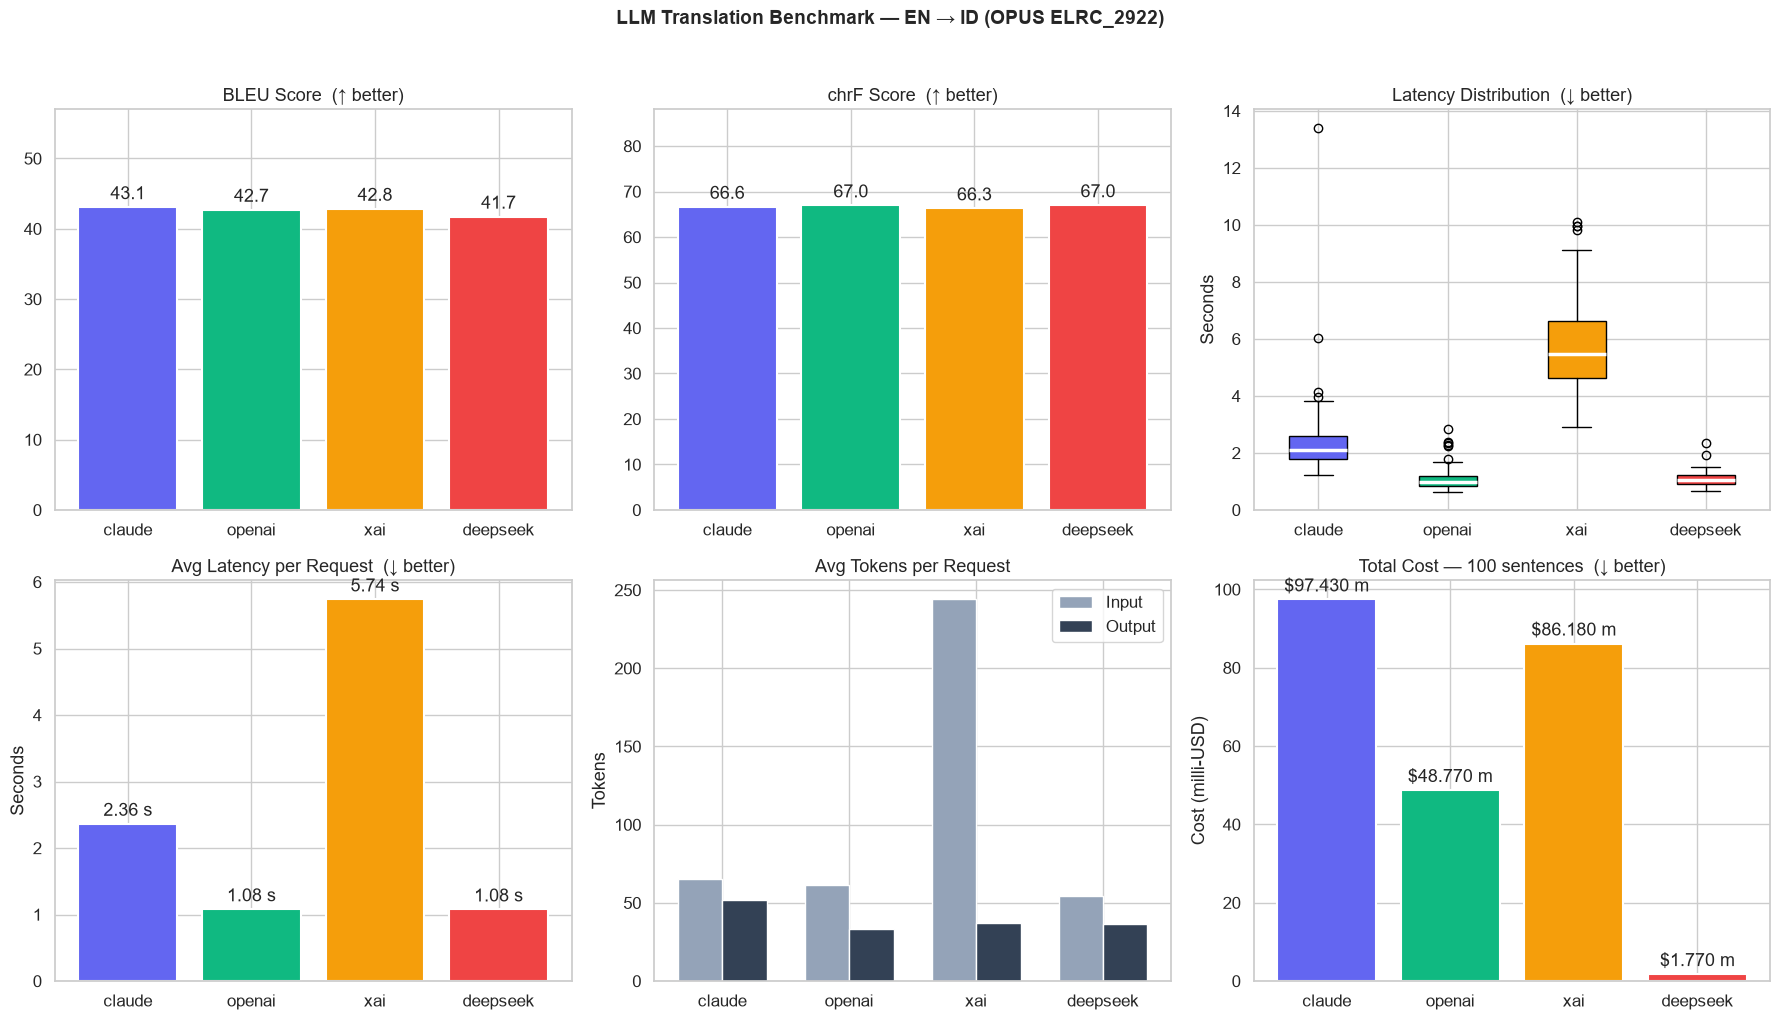

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE     = {"claude": "#6366f1", "openai": "#10b981", "xai": "#f59e0b", "deepseek": "#ef4444"}
MODEL_ORDER = [m for m in ["claude", "openai", "xai", "deepseek"] if m in df_summary.index]
COLORS      = [PALETTE[m] for m in MODEL_ORDER]

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LLM Translation Benchmark — EN → ID (OPUS ELRC_2922)", fontsize=14, fontweight="bold", y=1.02)

# 9.1 BLEU
ax = axes[0, 0]
vals = [df_summary.loc[m, "BLEU"] for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="%.1f", padding=3)
ax.set_title("BLEU Score  (↑ better)")
ax.set_ylim(0, max(vals) * 1.3 + 1)

# 9.2 chrF
ax = axes[0, 1]
vals = [df_summary.loc[m, "chrF"] for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="%.1f", padding=3)
ax.set_title("chrF Score  (↑ better)")
ax.set_ylim(0, max(vals) * 1.3 + 1)

# 9.3 Latency box
ax = axes[0, 2]
data_lat = [df_results[df_results["model"] == m]["latency_s"].values for m in MODEL_ORDER]
# bp = ax.boxplot(data_lat, labels=MODEL_ORDER, patch_artist=True,
#                 medianprops=dict(color="white", linewidth=2.5))
bp = ax.boxplot(data_lat, tick_labels=MODEL_ORDER, patch_artist=True,
                medianprops=dict(color="white", linewidth=2.5))
for patch, c in zip(bp["boxes"], COLORS):
    patch.set_facecolor(c)
ax.set_title("Latency Distribution  (↓ better)")
ax.set_ylabel("Seconds")

# 9.4 Avg latency bar
ax = axes[1, 0]
vals = [df_summary.loc[m, "avg_latency_s"] for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="%.2f s", padding=3)
ax.set_title("Avg Latency per Request  (↓ better)")
ax.set_ylabel("Seconds")

# 9.5 Token breakdown
ax = axes[1, 1]
x = range(len(MODEL_ORDER))
w = 0.35
in_toks  = [df_summary.loc[m, "avg_input_tok"]  for m in MODEL_ORDER]
out_toks = [df_summary.loc[m, "avg_output_tok"] for m in MODEL_ORDER]
ax.bar([xi - w/2 for xi in x], in_toks,  w, label="Input",  color="#94a3b8", edgecolor="white")
ax.bar([xi + w/2 for xi in x], out_toks, w, label="Output", color="#334155", edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(MODEL_ORDER)
ax.legend()
ax.set_title("Avg Tokens per Request")
ax.set_ylabel("Tokens")

# 9.6 Total cost in milli-USD
ax = axes[1, 2]
vals = [df_summary.loc[m, "total_cost_usd"] * 1000 for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="$%.3f m", padding=3)
ax.set_title(f"Total Cost — {N_SAMPLES} sentences  (↓ better)")
ax.set_ylabel("Cost (milli-USD)")

plt.tight_layout()
plt.savefig("fig/translation_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Cost vs Quality scatter

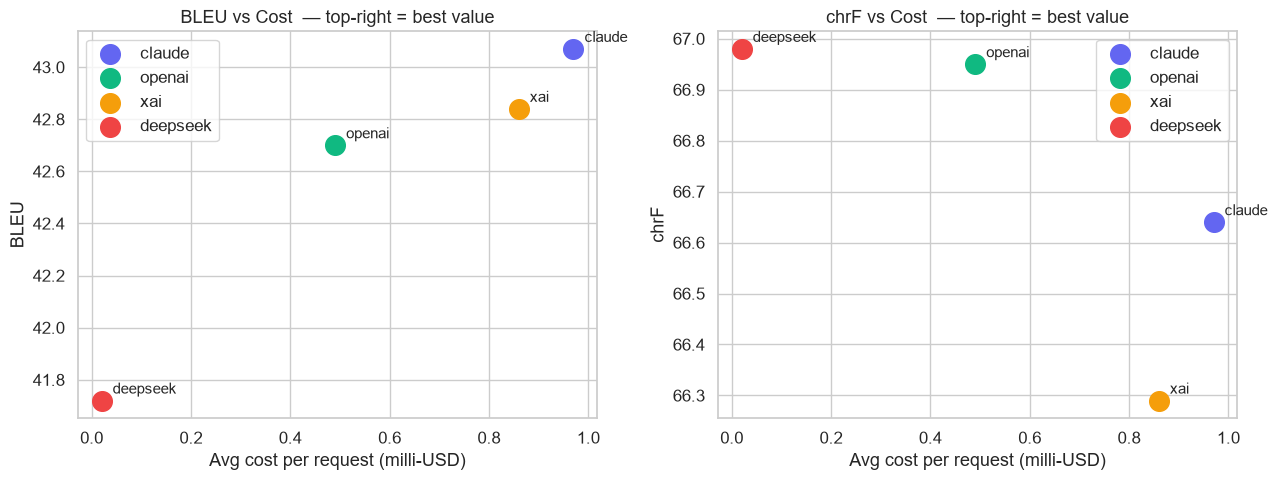

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ["BLEU", "chrF"]):
    for m in MODEL_ORDER:
        x = df_summary.loc[m, "avg_cost_usd"] * 1000
        y = df_summary.loc[m, metric]
        ax.scatter(x, y, s=200, color=PALETTE[m], zorder=5, label=m)
        ax.annotate(m, (x, y), textcoords="offset points", xytext=(8, 5), fontsize=11)
    ax.set_xlabel("Avg cost per request (milli-USD)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs Cost  — top-right = best value")
    ax.legend()

plt.tight_layout()
plt.savefig("fig/cost_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Side-by-side translation examples

In [14]:
N_SHOW = min(3, len(df_dataset))

for idx in range(N_SHOW):
    subset = df_results[df_results["sentence_idx"] == idx]
    print(f"\n{'='*80}")
    print(f"Sentence #{idx}")
    print(f"  SOURCE (EN):    {df_dataset.iloc[idx]['source_en']}")
    print(f"  REFERENCE (ID): {df_dataset.iloc[idx]['reference_id']}")
    for _, row in subset.iterrows():
        print(f"\n  [{row['model']:>8}]  {row['translation']}")
        print(f"            latency={row['latency_s']:.2f}s  "
              f"tokens={row['total_tokens']}  "
              f"cost=${row['cost_usd']*1000:.4f}m")


Sentence #0
  SOURCE (EN):    While there is tentative data that it is safe , and the animal data is promising , there is little human data as of 2017 .
  REFERENCE (ID): Meskipun secara umum aman dan dengan data hewan yang menjanjikan , data untuk manusia sangat kecil sejak 2014 .

  [  claude]  Meskipun terdapat data sementara yang menunjukkan bahwa hal itu aman, dan data pada hewan menjanjikan, terdapat sedikit data pada manusia hingga tahun 2017.
            latency=2.82s  tokens=119  cost=$1.0290m

  [  openai]  Meskipun ada data tentatif bahwa itu aman, dan data hewan menjanjikan, ada sedikit data manusia hingga 2017.
            latency=1.25s  tokens=89  cost=$0.4325m

  [     xai]  Meskipun ada data tentatif bahwa itu aman, dan data hewan menjanjikan, ada sedikit data manusia per 2017.
            latency=5.61s  tokens=274  cost=$0.7880m

  [deepseek]  Meskipun ada data sementara yang menunjukkan bahwa ini aman, dan data pada hewan cukup menjanjikan, data pada manusia masih sa

## 12. Final leaderboard

In [15]:
leaderboard = df_summary[[
    "BLEU", "chrF",
    "avg_latency_s", "p95_latency_s",
    "avg_input_tok", "avg_output_tok", "total_tokens",
    "avg_cost_usd", "total_cost_usd"
]].copy()

leaderboard["avg_cost_m"]   = (leaderboard.pop("avg_cost_usd")   * 1000).round(4)
leaderboard["total_cost_m"] = (leaderboard.pop("total_cost_usd") * 1000).round(4)
leaderboard.columns = [
    "BLEU", "chrF",
    "Avg Lat(s)", "P95 Lat(s)",
    "Avg InTok", "Avg OutTok", "Total Tok",
    "Avg Cost(m$)", "Total Cost(m$)"
]
leaderboard.sort_values("BLEU", ascending=False, inplace=True)

display(
    leaderboard.style
    .background_gradient(subset=["BLEU", "chrF"],            cmap="Greens")
    .background_gradient(subset=["Avg Lat(s)", "P95 Lat(s)"], cmap="Reds_r")
    .background_gradient(subset=["Total Cost(m$)"],           cmap="Oranges_r")
    .format(precision=3)
)

,BLEU,chrF,Avg Lat(s),P95 Lat(s),Avg InTok,Avg OutTok,Total Tok,Avg Cost(m$),Total Cost(m$)
model,,,,,,,,,
claude,43.070,66.640,2.364,3.749,65.130,51.930,11706,0.970,97.430
xai,42.840,66.290,5.737,8.918,243.970,37.390,28136,0.860,86.180
openai,42.700,66.950,1.078,1.823,61.570,33.380,9495,0.490,48.770
deepseek,41.720,66.980,1.076,1.413,54.400,36.190,9059,0.020,1.770


---
### Metric guide

| Metric | Direction | Notes |
|--------|-----------|-------|
| **BLEU** | ↑ higher is better | Exact n-gram overlap; strict |
| **chrF** | ↑ higher is better | Character F-score; better for morphologically rich languages like Indonesian |
| **Latency** | ↓ lower is better | Wall-clock time per API call |
| **Tokens** | ↓ lower is better | Prompt engineering can reduce input tokens |
| **Cost** | ↓ lower is better | Derived from official per-token pricing |



# Tugas

Cobalah evaluasi performa pilihan model Anthropic, OpenAI, xAI, DeepSeek lainnya pada dataset diatas 